In [56]:
import numpy as np
from scipy.stats import unitary_group

def digitize_real_number(x, L):
    """Convert a real number x in [0,1) to its binary representation as a list of bits."""
    binary_repr = f"{int(x * (2**L)):0{L}b}"
    return np.array([int(bit) for bit in binary_repr], dtype=int)

def apply_cyclic_leftward_shift_to_state(state, L):
    """
    Applies the cyclic leftward shift to each computational basis state.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis (2^L dimensional).
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The new state vector after applying the cyclic leftward shift.
    """
    # Initialize the new state as a zero vector
    new_state = np.zeros_like(state, dtype=complex)
    
    # Iterate over each computational basis state
    for i in range(2**L):
        # Convert index to binary representation (bit string)
        bit_string = f"{i:0{L}b}"
        
        # Apply the cyclic leftward shift to the bit string
        shifted_bit_string = bit_string[1:] + bit_string[0]
        
        # Convert the shifted bit string back to an integer index
        shifted_index = int(shifted_bit_string, 2)
        
        # Update the new state vector
        new_state[shifted_index] = state[i]
    
    return new_state

def get_last_two_qubit_indices(time, L):
    """
    Returns the indices of the last two qubits after a specified number of cyclic leftward shifts.
    
    Parameters:
    time (int): The current time step (number of cyclic leftward shifts applied).
    L (int): The total number of qubits.
    
    Returns:
    tuple: A tuple containing the indices of the last two qubits.
    """
    # Calculate the indices of the last two qubits after the shifts
    qubit1 = (L - 2 + time) % L
    qubit2 = (L - 1 + time) % L
    
    return qubit1, qubit2 
 
def embed_haar_to_full_unitary(L, target_qubits):
    """
    Embeds a Haar random matrix into a full unitary matrix for a system of L qubits.
    
    Parameters:
    L (int): Total number of qubits in the full system.
    target_qubits (list): List of two qubits where the Haar random unitary should be applied.
    
    Returns:
    np.ndarray: A full (2^L x 2^L) unitary matrix.
    """
    # Dimension of the full Hilbert space
    full_dim = 2**L
    
    # Initialize the subsystem unitary
    haar_matrix = unitary_group.rvs(4)

    # Initialize the full unitary as an identity matrix
    full_unitary = np.eye(full_dim, dtype=complex)
    
    # Iterate over all possible states of the remaining qubits
    for remaining_state in range(2**(L-2)):
        # Binary representation of the remaining qubits
        remaining_bits = f"{remaining_state:0{L-2}b}"
        
        # Iterate over all possible 2-qubit states
        for i in range(4):
            for j in range(4):
                # Binary representation of the smaller indices
                binary_i = f"{i:02b}"
                binary_j = f"{j:02b}"
                
                # Initialize full state indices
                full_index_i = list(remaining_bits)
                full_index_j = list(remaining_bits)
                
                # Map the 2-qubit binary strings to the target qubits in the full state
                full_index_i.insert(target_qubits[0], binary_i[0])
                full_index_i.insert(target_qubits[1], binary_i[1])
                full_index_j.insert(target_qubits[0], binary_j[0])
                full_index_j.insert(target_qubits[1], binary_j[1])
                
                # Convert the full indices back to integer form
                full_index_i = int("".join(full_index_i), 2)
                full_index_j = int("".join(full_index_j), 2)
                
                # Assign the corresponding value from the Haar matrix to the full unitary
                full_unitary[full_index_i, full_index_j] = haar_matrix[i, j]
    
    return full_unitary

def apply_bernoulli_map(state, L, time_step):
    """
    Apply the Bernoulli map to the quantum state.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis.
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The new state vector after applying the Bernoulli map.
    """
    # Step 1: Apply the cyclic left shift operation
    state = apply_cyclic_leftward_shift_to_state(state, L)
    
    # Step 2: Apply the Haar random unitary to the last two qubits
    target_qubits = get_last_two_qubit_indices(time_step, L)
    unitary = embed_haar_to_full_unitary(L, target_qubits)
    state = np.dot(unitary, state)
    # state /= np.linalg.norm(state)
    
    return state
import numpy as np

def binary_rep_fraction(fraction, L):
    """
    Generate the binary representation of a fraction with L bits.
    
    Parameters:
    fraction (float): The fraction to convert (e.g., 1/6 or 1/3).
    L (int): The number of bits (qubits) in the system.
    
    Returns:
    str: A binary string of length L representing the fraction.
    """
    binary_str = ""
    value = fraction
    for _ in range(L):
        value *= 2
        bit = int(value)
        binary_str += str(bit)
        value -= bit
    return binary_str

def apply_cyclic_right_shift_to_state(state, L):
    """
    Applies the cyclic right shift to each computational basis state.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis (2^L dimensional).
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The new state vector after applying the cyclic right shift.
    """
    new_state = np.zeros_like(state, dtype=complex)
    
    for i in range(2**L):
        # Convert index to binary representation (bit string)
        bit_string = f"{i:0{L}b}"
        
        # Apply the cyclic right shift to the bit string
        shifted_bit_string = bit_string[-1] + bit_string[:-1]
        
        # Convert the shifted bit string back to an integer index
        shifted_index = int(shifted_bit_string, 2)
        
        # Update the new state vector
        new_state[shifted_index] = state[i]
    
    return new_state

def apply_pauli_x_rightmost_qubit(L):
    """
    Constructs the Pauli-X gate that acts on the rightmost qubit in a system of L qubits.
    
    Parameters:
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The (2^L x 2^L) Pauli-X matrix acting on the rightmost qubit.
    """
    X_L = np.zeros((2**L, 2**L), dtype=complex)
    
    # Iterate over the first half of the basis states
    for i in range(2**L):
        if i % 2 == 0:
            X_L[i, i+1] = 1.0
            X_L[i+1, i] = 1.0
    
    return X_L

def measure_reset_rightmost_qubit(state, L):
    """
    Measure the rightmost qubit and reset it to the state |0>.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis.
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The state vector after the reset operation.
    """

    # Initialize the projector for the measurement P_L^0 and P_L^1
    P_L_0 = np.zeros((2**L, 2**L), dtype=complex)
    P_L_1 = np.zeros((2**L, 2**L), dtype=complex)
    
    # Define projectors for the rightmost qubit being 0 and 1
    for i in range(2**L):
        if i % 2 == 0:
            P_L_0[i, i] = 1.0
        else:
            P_L_1[i, i] = 1.0
    
    # Measure the rightmost qubit
    prob_0 = np.linalg.norm(np.dot(P_L_0, state))**2
    prob_1 = np.linalg.norm(np.dot(P_L_1, state))**2
    
    # Choose the outcome probabilistically based on the state's probabilities
    if np.random.rand() < prob_0:
        state = np.dot(P_L_0, state) / np.sqrt(prob_0)
    else:
        state = np.dot(P_L_1, state) / np.sqrt(prob_1)
        # Apply X gate if the measurement outcome was 1
        X_L = apply_pauli_x_rightmost_qubit(L)
        state = np.dot(X_L, state)
    
    return state

def apply_adder_operator(state, L):
    """
    Applies the adder operation A to the quantum state.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis.
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The new state vector after applying the adder operation.
    """
    new_state = np.zeros_like(state, dtype=complex)
    
    # Generate binary representations for 1/6 and 1/3 with L bits
    binary_1_6 = binary_rep_fraction(1/6, L)
    binary_1_3 = binary_rep_fraction(1/3, L)
    
    for i in range(2**L):
        bit_string = f"{i:0{L}b}"
        x_decimal = int(bit_string[:2], 2)  # Get the first two bits to determine the interval
        
        # Choose the appropriate adder based on the interval
        adder = binary_1_6 if x_decimal == 0 else binary_1_3
        
        # Convert bit strings to integers
        bit_string_int = int(bit_string, 2)
        adder_int = int(adder, 2)
        
        # Perform XOR operation to add modulo 2
        new_bit_string_int = (bit_string_int + adder_int) % (2**L)
        
        # Convert back to binary string
        new_bit_string = f"{new_bit_string_int:0{L}b}"
        
        # Update the state vector
        new_index = int(new_bit_string, 2)
        new_state[new_index] += state[i]
    
    return new_state

def apply_control_map_global(state, L):
    """
    Apply the global control map to the quantum state.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis.
    L (int): The number of qubits.
    
    Returns:
    np.ndarray: The new state vector after applying the global control map.
    """
    # Step 1: Measure and reset the rightmost qubit to 0
    state = measure_reset_rightmost_qubit(state, L)
    
    # Step 2: Apply the cyclic right shift operation
    state = apply_cyclic_right_shift_to_state(state, L)
    
    # Step 3: Apply the adder operator
    state = apply_adder_operator(state, L)
    
    return state

# # Test the global control map on all possible input states
# L = 3
# for i in range(2**L):
#     bit_string = f"{i:0{L}b}"
#     state = np.zeros(2**L, dtype=complex)
#     state[int(bit_string, 2)] = 1.0  
#     print('before: ', state, 'after: ', apply_control_map_global(state, L))

def simulate_once(x0, L, time, p_ctrol):
    """
    Simulate the quantum Bernoulli + global control map.
    
    Parameters:
    x0 (float): Initial real number to be digitized.
    L (int): Number of qubits in the system.
    time (int): Total time steps for the simulation.
    
    Returns:
    list: List of states after each time step.
    """
    # Digitize the initial state
    state = digitize_real_number(x0, L)
    
    # Convert to a full state vector in the computational basis
    full_state = np.zeros(2**L, dtype=complex)
    full_state[int("".join(map(str, state.astype(int))), 2)] = 1.0
    
    # Store the trajectory of the state
    trajectory = [full_state]
    
    # Perform the simulation
    for t in range(time):
        if np.random.rand() < p_ctrol:
            # Apply global control map
            full_state = apply_control_map_global(full_state, L)
        else:
            # Apply the Bernoulli map
            full_state = apply_bernoulli_map(full_state, L, t)
        
        # Normalize the state vector
        full_state /= np.linalg.norm(full_state)
        
        # Store the new state in the trajectory
        trajectory.append(full_state)
    
    return trajectory

# Simulate the random quantum circuit over num_iter iterations
def simulate(x0, L, time, p_ctrol, num_iter):
    """
    Simulate the quantum Bernoulli + global control map over multiple iterations.
    
    Parameters:
    x0 (float): Initial real number to be digitized.
    L (int): Number of qubits in the system.
    time (int): Total time steps for the simulation.
    num_iter (int): Number of iterations to run the simulation.
    
    Returns:
    list: List of trajectories for each iteration.
    """
    trajectories = []
    
    for _ in range(num_iter):
        trajectory = simulate_once(x0, L, time, p_ctrol)
        trajectories.append(trajectory)
    
    return np.mean(trajectories, axis=0) # we only need the mean of the trajectories, single trajectory is meaningless

# # Test the simulation
# # Parameters
# x0 = 1 / np.sqrt(2)  # Initial real number
# L = 4  # Number of qubits
# time = 10  # Total time steps for the simulation
# p_ctrol = 0.5  # Probability of applying the global control map
# num_iter = 100  # Number of iterations for the simulation

# # Simulate the quantum circuit
# mean_trajectory = simulate(x0, L, time, p_ctrol, num_iter)
# # Print the final state
# print("mean_trajectory:")
# print(mean_trajectory[-1])

In [57]:
def pauli_z_operator(L, qubit_index):
    """
    Constructs the Pauli-Z operator acting on the specified qubit in a system of L qubits.
    
    Parameters:
    L (int): The number of qubits.
    qubit_index (int): The index of the qubit on which the Pauli-Z operator acts.
    
    Returns:
    np.ndarray: The (2^L x 2^L) matrix representing the Pauli-Z operator on the specified qubit.
    """
    # Identity operator on 1 qubit
    I = np.eye(2, dtype=complex)
    # Pauli-Z operator on 1 qubit
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    
    # Tensor product to create the full operator
    operator = 1
    for i in range(L):
        if i == qubit_index:
            operator = np.kron(operator, Z)
        else:
            operator = np.kron(operator, I)
    
    return operator

def calculate_afm_neel_order(state, L):
    """
    Calculate the antiferromagnetic (AFM) Néel order parameter for a given quantum state.
    
    Parameters:
    state (np.ndarray): The state vector in the computational basis.
    L (int): The number of qubits.
    
    Returns:
    float: The average value of the AFM Néel order parameter.
    """
    # Initialize the AFM order parameter
    O_AFM = 0.0
    
    # Loop over each pair of qubits (i, i+1) with periodic boundary conditions
    for i in range(L):
        # Calculate Z_i Z_{i+1} with periodic boundary conditions
        Z_i = pauli_z_operator(L, i)
        Z_ip1 = pauli_z_operator(L, (i + 1) % L)
        
        # Combine Z_i and Z_{i+1}
        ZiZi1 = np.dot(Z_i, Z_ip1)
        
        # Calculate the expectation value <state| Z_i Z_{i+1} |state>
        expectation_value = np.vdot(state.conj(), np.dot(ZiZi1, state))
        
        # Accumulate the result
        O_AFM += expectation_value.real
    
    # Normalize by -1/L
    O_AFM = -O_AFM / L
    
    return O_AFM

# # Test the AFM Néel order parameter on all possible input states
# L = 4
# for i in range(2**L):
#     bit_string = f"{i:0{L}b}"
#     state = np.zeros(2**L, dtype=complex)
#     state[int(bit_string, 2)] = 1.0  
#     O_AFM = calculate_afm_neel_order(state, L)
#     print(f"AFM Néel order parameter: {O_AFM} for bit string {bit_string}")


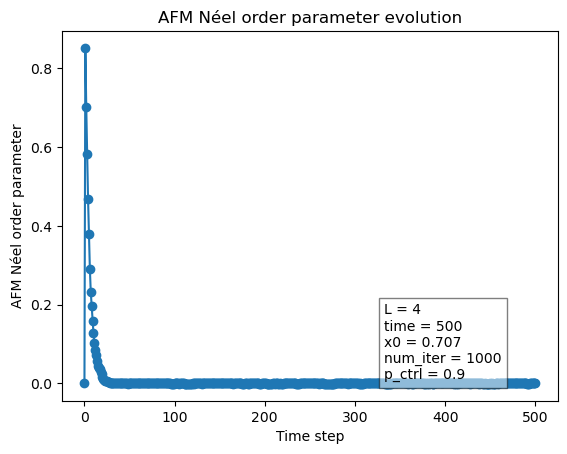

In [61]:
# See how the Neel order parameter evolves over time
def simulate_neel_order(x0, L, time, p_ctrol, num_iter):
    """
    Simulate the quantum Bernoulli + global control map and calculate the AFM Néel order parameter.
    
    Parameters:
    x0 (float): Initial real number to be digitized.
    L (int): Number of qubits in the system.
    time (int): Total time steps for the simulation.
    num_iter (int): Number of iterations to run the simulation.
    
    Returns:
    list: List of AFM Néel order parameters for each time step.
    """
    # Simulate the quantum circuit
    trajectories = simulate(x0, L, time, p_ctrol, num_iter)
    
    # Calculate the AFM Néel order parameter for each time step
    neel_order = [calculate_afm_neel_order(state, L) for state in trajectories]
    
    return neel_order

import matplotlib.pyplot as plt

# Parameters
L = 8  # Number of qubits
time = 2 * (L**2)  # Total time steps for the simulation
x0 = 1 / np.sqrt(2)  # Initial real number
num_iter = 2000  # Number of iterations for the simulation
p_ctrol = 0.9  # Probability of applying the global control map

# Simulate the quantum circuit and calculate the AFM Néel order parameter
neel_order = simulate_neel_order(x0, L, time, p_ctrol, num_iter)

# Plot the results
plt.plot(neel_order, marker='o')
plt.xlabel('Time step')
plt.ylabel('AFM Néel order parameter')
plt.title('AFM Néel order parameter evolution')

# Display the parameters on the plot
params_text = f'L = {L}\ntime = {time}\nx0 = {x0:.3f}\nnum_iter = {num_iter}\np_ctrl = {p_ctrol}'
plt.text(0.65, 0.05, params_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))

plt.show()

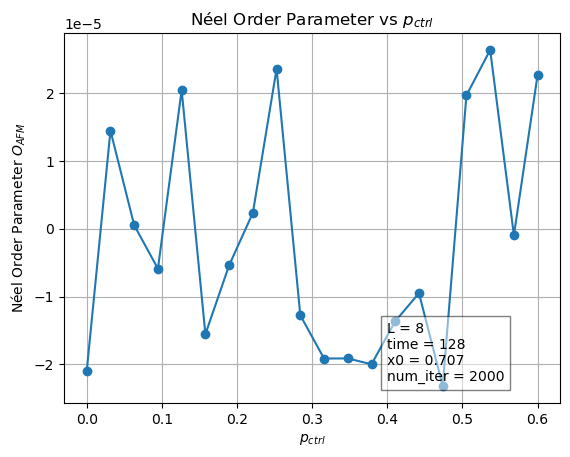

In [63]:
import matplotlib.pyplot as plt

# Parameters
L = 8  # Number of qubits
time = 2 * (L ** 2)  # Total time steps for the simulation
x0 = 1 / np.sqrt(2)  # Initial real number
num_iter = 2000  # Number of iterations for the simulation

# Run the simulation for different p_ctrl values and calculate the AFM Néel order
p_ctrl_values = np.linspace(0, 0.6, 20)
neel_order_values = []

for p_ctrl in p_ctrl_values:
    mean_trajectory = simulate(x0, L, time, p_ctrl, num_iter)
    neel_order = calculate_afm_neel_order(mean_trajectory[-1], L)
    neel_order_values.append(neel_order)

# Plot the results
plt.plot(p_ctrl_values, neel_order_values, marker='o')
plt.xlabel('$p_{ctrl}$')
plt.ylabel('Néel Order Parameter $O_{AFM}$')
plt.title('Néel Order Parameter vs $p_{ctrl}$')
plt.grid(True)

# Display the parameters on the plot
params_text = f'L = {L}\ntime = {time}\nx0 = {x0:.3f}\nnum_iter = {num_iter}'
plt.text(0.65, 0.05, params_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))

plt.show()